In [1]:
%gui tk
%matplotlib inline

from tkinter import Tk
from tkinter import filedialog
from pathlib import Path
import pandas as pd
from scipy.special import gamma
from scipy.optimize import curve_fit
import re
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import time
import cv2 as cv
from math import sqrt

import tweezers

# Scroll down to see explanations for the functions

In [2]:
"""one-cell code for a quicker workflow"""

# we use the filedialog of tkinter to ask for the data directory
# a graphical user interface like filedialog is preferred since it is less error prone 
# compared to copying and pasting the path
def askForDirectory():
    """
        Opens filedialog to select and return a directory path.
    """
    # since tkinter opens a new window when used, we withdraw that window to avoid clutter
    root = Tk()
    root.withdraw()
    # shows dialog box and returns the path
    dataDir = filedialog.askdirectory(initialdir = Path.home())
    root.update()
    print(f'selected directory: {dataDir}')
    return dataDir

def stretched_exponential(t, start, tau, offset, plateau, beta):
    """stretched exponential function used to fit the tweezer data."""
    def fusion(t):
        result = offset + (plateau - offset) * (1 - np.exp(-abs((t - start ) / tau)**beta))
        return result
    result = np.piecewise(t, [t < start, t >= start], [offset, lambda t:fusion(t)])   
    return result

def split_experiment_identifier(experimentIdentifier):
    """
    Takes experiment identifier string (which is the name of the folder 
    in which the data is saved at the BIOTEC tweezer) and splits it into experiment name and experiment date.
    Returns tuple (experimentName, experimentDate).
    """
    # TODO: make rePattern more general
    rePattern = r'(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})( )(.*?)( )?(#\d{3})?(-)?(\d{3})?( (PSD|IMAGE|DATA).*)?(/.*|$)'
    reObj = re.search(rePattern, experimentIdentifier)
    experimentDateTime = reObj.group(1)
    experimentName = reObj.group(3)
    experimentBead = reObj.group(5)
    experimentTrial = reObj.group(7)
    # convert time string into timestamp
    experimentDateTimestamp = time.mktime(datetime.strptime(experimentDateTime, "%Y-%m-%d_%H-%M-%S").timetuple())
    if experimentBead==None:
        return experimentName, experimentDateTimestamp
    if experimentTrial==None:
        return experimentName, experimentDateTimestamp, experimentBead
    experimentTrial = int(experimentTrial)
    return experimentName, experimentDateTimestamp, experimentBead, experimentTrial

def search_tweezer_data_directory(pathToDirectory, fileEnding='PSD.h5'):
    """
    Searches subdirectories containing Tweezer data by looking for a PSD.h5 file.
    Returns a python-generator. Iterating through this generator returns the subdirectories.
    """
    pathToDirectory = Path(pathToDirectory)
    globString = '**/*' + fileEnding
    filesGen = pathToDirectory.glob(globString)
    def count_files(dataDir):
        count = 0
        for path in dataDir.iterdir():
            if path.is_file() and not path.name.startswith('.'):
                count += 1
        if count==0:
            print(f"{pathToDirectory} does not contain tweezer data")
        return count   
    dataDirGen = (dataDir.parents[0] for dataDir in filesGen if count_files(dataDir.parents[0]) > 1)   
    return dataDirGen

def ForceCurveFit(t, path_str, plot_name, maxSigma=5, SavePlots=True):
    """Fits the data of the tweezers Data t to an stretched exponential and returns the time constant tau as well as an report.
        Used in the function 'FusionBIOTEC'
    
        INPUT
        
        t - tweezersData 
        path_str - path to the directory of the single experiments data
        plot_name - name of the plot which will be created
        maxTauSigma - 5; maximal percent standard deviation of the fitted time constant which is still considered fine
        ForceSave - False; if True, data for fits above maxTauSigma will still be saved
        SavePlots - True; if True, plots of the original data and the fits are saved in a subdirectory 'path/results/plots'
        
    
        OUTPUT
        
        p_val[1] - time constant of the stretched exponential fit
        report - report how succesful the fit was; 
                'fiterr' - fit was not possible, value - percent standard deviation of the time constant exceeding allowed maximum, None - no error
            
        REQUIREMENTS
        
        import pandas as pd
        from scipy.optimize import curve_fit
        import matplotlib.pyplot as plt
        from pathlib import Path
        import tweezers
        selfdefined function stretched_exponential
    """
       
    data = t.source.getData()
    
    # find middle value dataset and define cut offs
    mid = (data.aodXDiff.min() + data.aodXDiff.max()) /2
    mid_pos =(data['aodXDiff']-mid).abs().argsort()[0]
    co_start, co_end = int(mid_pos - len(data)/6), int(mid_pos + len(data)/3)
    if co_start < 0:
        co_start = 0
    if co_end >= len(data):
        co_end = -1
        
    co_start, co_end = 0, -1
    
    experimentStart = data.absTime[0]
    time = data.absTime - experimentStart
    
    t_val = np.array(time[co_start:co_end])
    f_val = np.array(-data.aodXDiff[co_start:co_end])
    p0=[t_val[0], 1, f_val[0], f_val[-1], 1] #start, tau, offset, plateau, exponent beta; initial guess of the fit parameters
    
    try:
        p_val, p_var = curve_fit(stretched_exponential, xdata = t_val, ydata = f_val, p0=p0)
    except:
        # Check: Fit possible
        report = 'fiterr'
        values = [None, None, None, None, None]
        return values, report
    else:
        # Check: percent standard deviation below defined maximum
        p_std = np.sqrt(abs(np.diag(p_var)))
        TauSigma = abs(p_std[1] / p_val[1] * 100)
        BetaSigma = abs(p_std[4] / p_val[4] * 100)
        if TauSigma > maxSigma:
            report = 'tau'
        elif BetaSigma > maxSigma:
            report = 'alpha'
        else:
            report = None

        if SavePlots:
            # plotting initial data (blue), fit (green), fit - standard deviation (red), fit + standard deviation (yellow)
            fig, ax = plt.subplots()
            ax.plot(time,-data.aodXDiff, c='blue', marker='.', ls='', ms='1')
            ax.plot(t_val, stretched_exponential(np.array(t_val), p_val[0], p_val[1], p_val[2], p_val[3], p_val[4]), 'g')
            ax.plot(t_val, stretched_exponential(np.array(t_val), p_val[0] - p_std[0], p_val[1] - p_std[1], p_val[2] - p_std[2], p_val[3] - p_std[3],  p_val[4] - p_std[4]), 'r')
            ax.plot(t_val, stretched_exponential(np.array(t_val), p_val[0] + p_std[0], p_val[1] + p_std[1], p_val[2] + p_std[2], p_val[3] + p_std[3],  p_val[4] + p_std[4]), 'y')
            ax.set_xlabel('time t [s]')
            ax.set_ylabel('Voltage V')
            ax.set_title(plot_name)
            print('saved plot: ', plot_name)
            plot_name = plot_name + '.png'
            fig.savefig(path_str / 'results' / 'plots' / plot_name)
            plt.close()
        
        values = [p_val[1], p_std[1], p_val[4], p_std[4], data.absTime[0] + p_val[0]] # tau, tau_std, beta, alpha_std, fusionStartTimestamp
         
    return values, report

def img_mradius_21_03(img, savePath=None, crp=[0,0,-1,-1], ks=5, thr=250, scale=1):
    """
    Uses openCV to draw a circle around the dropelts and measure the radius of that circle.
    Since this is not always reliable, it is recommended to always check the found circles.
    """
    x_start = crp[0]
    y_start = crp[1]
    x_end = crp[2]
    y_end= crp[3]
    
    crop = img[y_start:y_end, x_start:x_end]

    mb1 = cv.medianBlur(crop, ks)
    lapl = cv.Laplacian(mb1, ddepth=-1, ksize=ks)
    equ = cv.equalizeHist(lapl)
    ____, thr = cv.threshold(equ, thr, 255, cv.THRESH_BINARY)
    mb2 = cv.medianBlur(thr, ks-2)

    pos_drops = np.zeros(np.shape(mb2)[1])
    pos_inv = np.zeros(np.shape(mb2)[1])

    for i in range(np.shape(mb2)[1]):
        if np.sum(mb2,axis=0)[i] != 0:
            pos_drops[i] = i
        else:
            pos_inv[i] = i
        
    mid = int(np.sum(pos_drops) / len(pos_drops[pos_drops!=0]))
    cut = (np.abs(mid - pos_inv)).argsort()[0]

    part1 = mb2[:,:cut].copy()
    part2 = mb2[:,cut:].copy()
    
    #part 1

    contours, hierarchy = cv.findContours(part1, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    
    # Check: No contours found (part1)
    if len(contours)==0:
        r1 = 0
        c1 = (0,0)
        img_err_1 = 1
    
    else:
        for cnt in contours:
            cv.drawContours(part1,[cnt],0,255,-1)
        contours, hierarchy = cv.findContours(part1, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    
        # Check: No contours found (2nd time)
        if len(contours) == 0:
            r1 = 0
            c1 = (0,0)
            img_err_1 = 1
    
        elif len(contours) >=1:
            for i in range(1, len(contours)):
                cv.line(part1, tuple(contours[i-1][0][0]), tuple(contours[i][0][0]),(255,255,255))
        
            contours, hierarchy = cv.findContours(part1, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
            c1, r1 = cv.minEnclosingCircle(contours[0])
            img_err_1 = 0

    #part 2
    
    contours, hierarchy = cv.findContours(part2, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    
    # Check: No contours found
    if len(contours)==0:
        r2 = 0
        c2 = (0,0)
        img_err_2 = 1    
    
    else:
        for cnt in contours:
            cv.drawContours(part2,[cnt],0,255,-1)
        contours, hierarchy = cv.findContours(part2, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    
        # Check: No contours found (2nd time)
        if len(contours) == 0:
            r2 = 0
            c2 = (0,0)
            img_err_2 = 1

        elif len(contours) >=1:
            for i in range(1, len(contours)):
                cv.line(part2, tuple(contours[i-1][0][0]), tuple(contours[i][0][0]),(255,255,255))
        
            contours, hierarchy = cv.findContours(part2, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
            c2, r2 = cv.minEnclosingCircle(contours[0])
            img_err_2 = 0

    copy = imageLarge3C = cv.merge((crop, crop, crop))
    cv.circle(copy, (int(c1[0]), int(c1[1])), int(r1), (255,255,0), thickness=1)
    cv.circle(copy, (cut+int(c2[0]), int(c2[1])), int(r2), (255,255,0), thickness=1)

    if savePath:
        cv.imwrite(savePath.as_posix(), copy)
    
    img_err = img_err_1 + img_err_2
    
    if img_err == 0:
        mean_radius = sqrt(r1*r2)
        # 1 pixel equals 0.043 um
        mean_radius = mean_radius*0.043
    else:
        mean_radius = 0
    
    return mean_radius, img_err

def fusion_BIOTEC_new(SavePlots=True, SaveDF=True, FitPara = None, ImgPara = None):
    """Main Function  for analysis of droplet fusion data from the BIOTEC
    
        INPUT
        
        path_str - string of the path to the Dataset
        SavePlots - True; if True, a subdirectory 'path_str/results/plots' will be created and the plots of all Fits will be saved
        SaveDF - True; if True, a subdirectory 'path_str/results' will be created and the final dataframe will be saved as a .pkl
        FitPara - None; can be used to set addtionial parameters of ForceCurveFit:
                    FitPara - maxTauSigma (=5) defines the maximal acceptable percent standard deviation of the the time constant tau
        ImgPara - None; can be used to set additional parameters of img_mradius:
                    ImgPara[0] - crp (=[0,0,-1,-1]) used to crop the picture, Array [x_start, y_start, x_end, y_end]
                    ImgPara[1] - ks (=5) kernelsize of medianBlur an calculating the Laplacian
                    ImgPara[2] - thr (=250) threshold value
                    ImgPara[3] - scale (=1) Pixel to um ratio
                    
        OUTPUT
        
        df - pandas Dataframe - columns= 'bead', 'trial','error', 'radius', 'tau [s]', 'tau_std [s]', 'alpha', 'alpha_std', 'start_absTime';
                    contains the obtained data; if fit or image analysis was not possible, the according values will be 'None'
        report - array; contains the report of all errors and problem occured during the analysis; can be read using reportReader()
        
        REQUIREMENTS
        
        import numpy as np
        import pandas as pd
        from scipy.optimize import curve_fit
        import matplotlib.pyplot as plt

        from pathlib import Path
        import tweezers

        import cv2 as cv
        
        selfdefined function 'stretched_exponential'
    """
    path_str = askForDirectory()
    
    # convert path_str to Path object making this code applicable for every operating system
    path = Path(path_str)
    
    # uses search_tweezer_data_directory function to find all folders with tweezer data
    subDirGen = search_tweezer_data_directory(path)
        
    # each bead is a new subdirectory
    # therefore we loop the analysis code over each subdirectory
    for subDir in subDirGen:
        print(f'analysing measurement in {subDir}')
        # we create an empty table using the pandas library and specify its columns
        df = pd.DataFrame(columns=['experiment date', 'fusion start', 'experiment name', 'bead', 'trial','error', 
                                   'tau', 'tau_std', 'beta', 'beta_std', 'relTime', 'mean radius'])
        # creating new subdirectory for each measurement series to save results
        if SavePlots or SaveDF:
            Path(subDir / 'results').mkdir(parents=True, exist_ok=True)
        if SavePlots:
            Path(subDir / 'results' / 'plots').mkdir(parents=True, exist_ok=True)
            Path(subDir / 'results' / 'figures').mkdir(parents=True, exist_ok=True)
            
            # I hope this will be read
            print()
            print()
            print('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
            print('!!!!       please make sure to check the images at "results/figures" and      !!!!')
            print('!!!!adjust the found geometric mean radii in the csv (or excel) file if needed!!!!')
            print('!!!! you can use Fiji to measure the radii manually (1 pixel equals 0.043 um) !!!!')
            print('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
            print()
            print()
            
        # using custom tweezers module to load the tweezer data
        # this data is stored in a table format
        td = tweezers.TweezersDataCollection.load(subDir, source=tweezers.io.Hdf5BiotecSource)[0]
        # getting all images of the measuremnt series
        # these images were taken automatically at the start of data recording
        fileList = [file.name for file in subDir.glob('*.png')]
        fileList.sort()
        
        # since a measurement series consists of multiple trials, we have to analyse
        # each trial separately (looping over each trial)
        for i in range(len(td)):
            imageName = fileList[i]
            # we get information on name, date, bead number and trial number from the image file name
            # these information are 
            experimentName, experimentDateTimestamp, experimentBead, experimentTrial = split_experiment_identifier(imageName)
            print(f'analysing trial {experimentTrial}')
            t = td[i]
            # we fit the stretched exponential function on the tweezer data
            if FitPara == None:
                values, fit_report = ForceCurveFit(t, subDir, plot_name = experimentBead+'_'+str(experimentTrial), SavePlots = SavePlots)
            else:
                values, fit_report = ForceCurveFit(t, subDir, plot_name = experimentBead+'_'+str(experimentTrial), maxSigma = FitPara, SavePlots = SavePlots)
            
            imagePath = (subDir / imageName).as_posix()
            if SavePlots:
                imageSavePath = subDir / 'results' / 'figures' / imageName
            else:
                imageSavePath = None
            img = cv.imread(imagePath, cv.IMREAD_GRAYSCALE)
            if ImgPara == None:
                mean_radius, img_report = img_mradius_21_03(img, imageSavePath)
            else:
                mean_radius, img_report = img_mradius_21_03(img, imageSavePath, crp=ImgPara[0], ks=ImgPara[1], thr=ImgPara[2], scale=ImgPara[3])   
                
            error = 0
                
            #Checks: reports from Fit: fiterr - fit not possible; value - percent standard deviation too high; None - no error
            #report from Image Analysis: 0 - no contours found; 1 - only one contour found, still used as mean radius
            if fit_report == 'fiterr':
                error = 1
            elif fit_report == 'tau':
                error = 1
            elif fit_report == 'beta':
                error = 1
            if img_report != 0:
                error = 1
            
            # calculate and fix time (since the tweezer records false date values)
            expDatetime = datetime.fromtimestamp(experimentDateTimestamp)
            expStartDateString = expDatetime.strftime('%Y-%m-%d')
            expStartTimeString = expDatetime.strftime('%H-%M-%S')
            
            tau, tau_std, beta, beta_std, fusionStartTimestamp = values
            if tau:
                if tau < 0:
                    error = 1
                fusionStartDatetime = datetime.fromtimestamp(fusionStartTimestamp)
                fusionStartString = fusionStartDatetime.strftime('%H-%M-%S')
            
            def calculate_relative_time(expDatetime, fusionStartDatetime):
                def calculate_total_seconds(datetime):
                    timeIdentifiers = ['%H', '%M', '%S']
                    timeList = [int(datetime.strftime(identifier)) for identifier in timeIdentifiers]
                    timeConstants = [3600, 60, 1]
                    totalSeconds = sum([a*b for a,b in zip(timeList, timeConstants)])
                    return totalSeconds
                
                # taking care of experiments that last longer than one day, for example from 23:00 to 1:00
                expHour = int(expDatetime.strftime('%H'))
                fusionStartHour = int(fusionStartDatetime.strftime('%H'))
                if expHour >= 7 and fusionStartHour < 7:
                    relTime = calculate_total_seconds(fusionStartDatetime) - calculate_total_seconds(expDatetime) + 3600*24
                    expDatetime = expDatetime + timedelta(days=1)
                else:
                    relTime = calculate_total_seconds(fusionStartDatetime) - calculate_total_seconds(expDatetime)
                expStartDateString = expDatetime.strftime('%Y-%m-%d')
                return relTime, expStartDateString
            
            relTime, expStartDateString = calculate_relative_time(expDatetime, fusionStartDatetime)
        
            if relTime < 0:
                error = 1
            
            # save data in new row of the dataframe
            dfi = pd.DataFrame([[expStartDateString, fusionStartString, experimentName, experimentBead, experimentTrial, 
                                error, tau, tau_std, beta, beta_std, relTime, mean_radius]], 
                               columns=df.columns)
            # we concatenate the individual rows into a single table containing data of the whole measurement series
            df = pd.concat([df, dfi], ignore_index=True)
        
        # we save the table with the analysed data as a csv file in the newly created results subdirectory
        if SaveDF == True:
            fileName = expStartDateString+'_'+expStartTimeString+' '+experimentName+' '+experimentBead+'.csv'
            df.to_csv(subDir / 'results' / fileName)

In [3]:
fusion_BIOTEC_new(SavePlots=True, SaveDF=True, FitPara = None, ImgPara = None)

selected directory: /Users/akasharavindan/Desktop/Thesis DATA/fusion/mixing experiment/2021-08-24_12-49-28 EWSR1 _3um_150mMkcl_trial2 #000
analysing measurement in /Users/akasharavindan/Desktop/Thesis DATA/fusion/mixing experiment/2021-08-24_12-49-28 EWSR1 _3um_150mMkcl_trial2 #000


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!       please make sure to check the images at "results/figures" and      !!!!
!!!!adjust the found geometric mean radii in the csv (or excel) file if needed!!!!
!!!! you can use Fiji to measure the radii manually (1 pixel equals 0.043 um) !!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


analysing trial 0


<ipython-input-2-fbbd28ddaa95>:22: RuntimeWarning: overflow encountered in power
  result = offset + (plateau - offset) * (1 - np.exp(-abs((t - start ) / tau)**beta))


saved plot:  #000_0
analysing trial 1
saved plot:  #000_1
analysing trial 2
saved plot:  #000_2
analysing trial 3
saved plot:  #000_3
analysing trial 4
saved plot:  #000_4
analysing trial 5
saved plot:  #000_5
analysing trial 6
saved plot:  #000_6
analysing trial 7
saved plot:  #000_7
analysing trial 8
saved plot:  #000_8
analysing trial 9
saved plot:  #000_9
analysing trial 10


<ipython-input-2-fbbd28ddaa95>:22: RuntimeWarning: overflow encountered in power
  result = offset + (plateau - offset) * (1 - np.exp(-abs((t - start ) / tau)**beta))


saved plot:  #000_10
analysing trial 11
saved plot:  #000_11
analysing trial 12
saved plot:  #000_12
analysing trial 13
saved plot:  #000_13
analysing trial 14
saved plot:  #000_14
analysing trial 15
saved plot:  #000_15
analysing trial 16
saved plot:  #000_16
analysing trial 17
saved plot:  #000_17
analysing trial 18
saved plot:  #000_18
analysing trial 19
saved plot:  #000_19
analysing trial 20
saved plot:  #000_20
analysing trial 21
saved plot:  #000_21
analysing trial 22
saved plot:  #000_22
analysing trial 23
saved plot:  #000_23
analysing trial 24
saved plot:  #000_24
analysing trial 25
saved plot:  #000_25
analysing trial 26
saved plot:  #000_26
analysing trial 27
saved plot:  #000_27
analysing trial 28
saved plot:  #000_28
analysing trial 29
saved plot:  #000_29


# code explanation

## askForDirectory function
we use the filedialog of tkinter to ask for the data directory<br>
a graphical user interface like filedialog is preferred since it is less error prone<br>
compared to copying and pasting the path

In [6]:
%gui tk

from tkinter import Tk
from tkinter import filedialog
from pathlib import Path

def askForDirectory():
    """
        Opens filedialog to select and return a directory path.
    """
    # since tkinter opens a new window when used, we withdraw that window to avoid clutter
    root = Tk()
    root.withdraw()
    # shows dialog box and returns the path
    dataDir = filedialog.askdirectory(initialdir = Path.home())
    root.update()
    print(f'selected directory: {dataDir}')
    return dataDir

example on how to use

In [7]:
askForDirectory()

selected directory: /Users/akasharavindan/Desktop/Thesis DATA/fusion/2021-09-20_14-33-22 EWSR1_EE_20_1 #000


'/Users/akasharavindan/Desktop/Thesis DATA/fusion/2021-09-20_14-33-22 EWSR1_EE_20_1 #000'

this function uses python to open your computers filedialog:<br>
![](askForDirectory1.png)
<br>
select the directory that contains the tweezer data

# stretched_exponential function

we use the stretched exponential to describe the forcecurve of two coalescing droplets

In [ ]:
import numpy as np

def stretched_exponential(t, start, tau, offset, plateau, beta):
    """stretched exponential function used to fit the tweezer data."""
    def fusion(t):
        result = offset + (plateau - offset) * (1 - np.exp(-abs((t - start ) / tau)**beta))
        return result
    result = np.piecewise(t, [t < start, t >= start], [offset, lambda t:fusion(t)])   
    return result

example on how to use

In [ ]:
%matplotlib inline

from matplotlib import pyplot as plt
from stretched_exponential import stretched_exponential

x = [t for t in range(1000)]
y = [stretched_exponential(t, 400, 50, 0, 300, 1) for t in x]
plt.plot(x, y)
plt.show()

# split_experiment_identifier function

since information on the experiment is also saved in the filenames, we need to extract this information back

In [2]:
import re
import time
from datetime import datetime

def split_experiment_identifier(experimentIdentifier):
    """
    Takes experiment identifier string (which is the name of the folder 
    in which the data is saved at the BIOTEC tweezer) and splits it into experiment name and experiment date.
    Returns tuple (experimentName, experimentDate).
    """
    # TODO: make rePattern more general
    rePattern = r'(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})( )(.*?)( )?(#\d{3})?(-)?(\d{3})?( (PSD|IMAGE|DATA).*)?(/.*|$)'
    reObj = re.search(rePattern, experimentIdentifier)
    experimentDateTime = reObj.group(1)
    experimentName = reObj.group(3)
    experimentBead = reObj.group(5)
    experimentTrial = reObj.group(7)
    # convert time string into timestamp
    experimentDateTimestamp = time.mktime(datetime.strptime(experimentDateTime, "%Y-%m-%d_%H-%M-%S").timetuple())
    if experimentBead==None:
        return experimentName, experimentDateTimestamp
    if experimentTrial==None:
        return experimentName, experimentDateTimestamp, experimentBead
    experimentTrial = int(experimentTrial)
    return experimentName, experimentDateTimestamp, experimentBead, experimentTrial

example on how to use

In [3]:
nameOfFile = '2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000-005 DATA.h5'

(experimentName, 
 experimentDateTimestamp, 
 experimentBead, 
 experimentTrial) = split_experiment_identifier(nameOfFile)

print(f'name of experiment: {experimentName}')
print(f'performt on: {datetime.fromtimestamp(experimentDateTimestamp)}')
print(f'number of bead: {experimentBead}')
print(f'number of trial: {experimentTrial}')

name of experiment: EWSR1_EE_10_1_DNA
performt on: 2021-08-25 12:37:22
number of bead: #000
number of trial: 5


# search_tweezer_data_directory function

since experiments can be performed on different days it is necessary to rearrange data into corresponding folders <br>
this leads to a branched directory structure: <br>
![](branched_directory_structure1.png)

tweezer data could be distributed over several subfolders and subfolders of subfolders <br>
therefore, it is necessary to find all the directories that contain tweezer data

In [4]:
from pathlib import Path

def search_tweezer_data_directory(pathToDirectory, fileEnding='PSD.h5'):
    """
    Searches subdirectories containing Tweezer data by looking for a PSD.h5 file.
    Returns a python-generator. Iterating through this generator returns the subdirectories.
    """
    pathToDirectory = Path(pathToDirectory)
    globString = '**/*' + fileEnding
    filesGen = pathToDirectory.glob(globString)
    def count_files(dataDir):
        count = 0
        for path in dataDir.iterdir():
            if path.is_file() and not path.name.startswith('.'):
                count += 1
        if count==0:
            print(f"{pathToDirectory} does not contain tweezer data")
        return count   
    dataDirGen = (dataDir.parents[0] for dataDir in filesGen if count_files(dataDir.parents[0]) > 1)   
    return dataDirGen

example on how to use

In [5]:
pathToTweezerData =  '../Akash'

dataDirGen = search_tweezer_data_directory(pathToTweezerData)
print('found tweezer data in following directories:')
for dir in dataDirGen:
    print(dir)

found tweezer data in following directories:


# ForceCurceFit function

since the measured data always comes with some noise, we need to approximated the measured curve by fitting a function to the data <br>
for example a typical forcecurve looks like this:

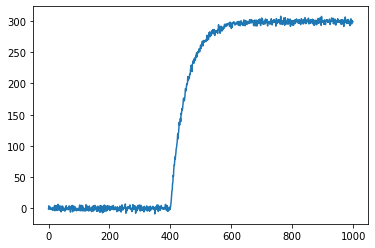

In [21]:
%matplotlib inline

from matplotlib import pyplot as plt
import numpy as np

from stretched_exponential import stretched_exponential

x = [t for t in range(1000)]
y = [stretched_exponential(t, 400, 50, 0, 300, 1) for t in x]
noise = np.random.normal(0, 3, (len(y), ))
noisy_y = y + noise
fig, ax = plt.subplots()
ax.plot(x, noisy_y)
plt.show()

since we know that the fitted function must be a stretched exponential, we can use the curve_fit method from scipy.optimize

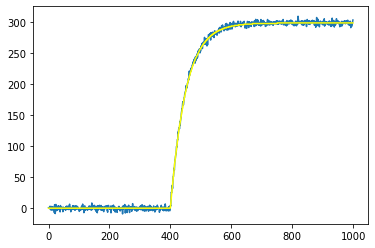

fitted tau: 50.55514711420959


In [20]:
%matplotlib inline

from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

from stretched_exponential import stretched_exponential

x = [t for t in range(1000)]
y = [stretched_exponential(t, 400, 50, 0, 300, 1) for t in x]
noise = np.random.normal(0, 3, (len(y), ))
noisy_y = y + noise
# initial guess of the fit parameters
p0 = [x[0], 1, y[0], y[-1], 1] #start, tau, offset, plateau, exponent beta

p_val, p_var = curve_fit(stretched_exponential, xdata=x, ydata=noisy_y, p0=p0)
start, tau, offset, plateau, beta = p_val
fitted_y = stretched_exponential(x, start, tau, offset, plateau, beta)

# plotting the result
fig, ax = plt.subplots()
ax.plot(x, noisy_y)
ax.plot(x, fitted_y, 'yellow')
plt.show()

print(f'fitted tau: {abs(tau)}')
plt.close()

loading data from BIOTEC tweezer data file into pandas dataframe

In [8]:
import tweezers

t = tweezers.TweezersDataCollection.load('example_data/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000/', source=tweezers.io.Hdf5BiotecSource)[0]
# selecting fifth recording from measurement series
dataframe = t[4].source.getData()
# you can also select other recordings from the example data
# but this one works good
dataframe

,absTime,pmXDiff,pmXSum,pmYDiff,pmYSum,aodXDiff,aodXSum,aodYDiff,aodYSum,pmXTrap,...,aodXTrap,aodYTrap,pmXBead,pmYBead,aodXBead,aodYBead,flowCellX,flowCellY,pressure,experimentState
0,3.712733e+09,-0.033422,0.031133,0.039933,0.030573,0.010056,-0.085673,0.023550,0.037618,24998.041044,...,15601.639715,7181.291601,0.000000,0.000000,0.000000,0.000000,44679.0,25370.0,0.997525,0.0
1,3.712733e+09,-0.033425,0.031133,0.039982,0.030573,0.010037,-0.085673,0.023546,0.037618,24998.021214,...,15601.639715,7181.291601,0.000000,0.000000,0.000000,0.000000,44679.0,25370.0,0.997525,0.0
2,3.712733e+09,-0.033392,0.029612,0.039995,0.030373,0.010048,-0.086113,0.023573,0.038419,24998.058396,...,15601.639715,7181.291601,0.000000,0.000000,0.000000,0.000000,44679.0,25370.0,0.997685,0.0
3,3.712733e+09,-0.033509,0.028091,0.039944,0.030173,0.010072,-0.086553,0.023606,0.039219,24998.014343,...,15601.639715,7181.291601,0.000000,0.000000,0.000000,0.000000,44679.0,25370.0,0.997846,0.0
4,3.712733e+09,-0.033559,0.028091,0.039934,0.030173,0.010129,-0.086553,0.023673,0.039219,24998.106619,...,15601.639715,7181.291601,0.000000,0.000000,0.000000,0.000000,44679.0,25370.0,0.997846,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113487,3.712733e+09,-0.038935,0.028652,0.039976,0.028932,0.005618,-0.082951,0.024373,0.032975,24998.155181,...,19783.639715,7181.291601,4689.307005,6309.706779,4689.307005,6309.706779,44679.0,25370.0,1.000367,0.0
113488,3.712733e+09,-0.039130,0.026250,0.039805,0.028892,0.005424,-0.085833,0.024177,0.035056,24998.226614,...,19783.639715,7181.291601,4689.307005,6309.706779,4689.307005,6309.706779,44679.0,25370.0,1.001128,0.0
113489,3.712733e+09,-0.038953,0.026250,0.039732,0.028892,0.005712,-0.085833,0.024425,0.035056,24998.336810,...,19783.639715,7181.291601,4689.307005,6309.706779,4689.307005,6309.706779,44679.0,25370.0,1.001128,0.0
113490,3.712733e+09,-0.038879,0.029372,0.039699,0.028892,0.005688,-0.084232,0.024467,0.036738,24998.225489,...,19783.639715,7181.291601,4689.307005,6309.706779,4689.307005,6309.706779,44679.0,25370.0,1.000808,0.0


plot force curve

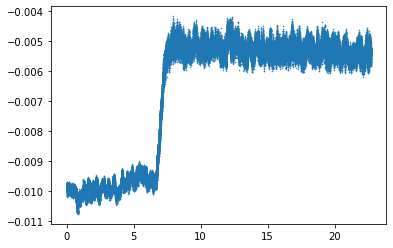

In [19]:
%matplotlib inline

from matplotlib import pyplot as plt
import tweezers

td = tweezers.TweezersDataCollection.load('example_data/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000/', source=tweezers.io.Hdf5BiotecSource)[0]
t = td[4]
data = t.source.getData()
    
# find middle value dataset and define cut offs
mid = (data.aodXDiff.min() + data.aodXDiff.max()) /2
mid_pos =(data['aodXDiff']-mid).abs().argsort()[0]
co_start, co_end = int(mid_pos - len(data)/6), int(mid_pos + len(data)/3)
if co_start < 0:
    co_start = 0
if co_end >= len(data):
    co_end = -1
        
co_start, co_end = 0, -1
    
experimentStart = data.absTime[0]
time = data.absTime - experimentStart    

fig, ax = plt.subplots()
ax.plot(time,-data.aodXDiff, marker='.', ls='', ms='1')
plt.show()
plt.close()

fit stretched exponential into force curve

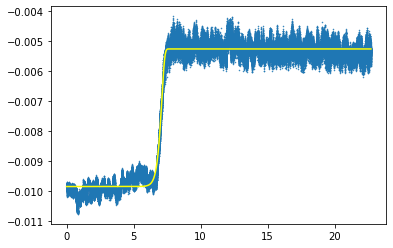

fitted tau: 3533.105917168711


In [18]:
%matplotlib inline

from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import tweezers

from stretched_exponential import stretched_exponential

td = tweezers.TweezersDataCollection.load('example_data/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000/', source=tweezers.io.Hdf5BiotecSource)[0]
t = td[4]
data = t.source.getData()
    
# find middle value dataset and define cut offs
mid = (data.aodXDiff.min() + data.aodXDiff.max()) /2
mid_pos =(data['aodXDiff']-mid).abs().argsort()[0]
co_start, co_end = int(mid_pos - len(data)/6), int(mid_pos + len(data)/3)
if co_start < 0:
    co_start = 0
if co_end >= len(data):
    co_end = -1
        
co_start, co_end = 0, -1
    
experimentStart = data.absTime[0]
time = data.absTime - experimentStart

# initial guess of the fit parameters
t_val = np.array(time[co_start:co_end])
f_val = np.array(-data.aodXDiff[co_start:co_end])
p0=[t_val[0], 1, f_val[0], f_val[-1], 1] #start, tau, offset, plateau, exponent beta

# fitting stretched exponential into force curve
p_val, p_var = curve_fit(stretched_exponential, xdata=t_val, ydata=f_val, p0=p0)

fig, ax = plt.subplots()
ax.plot(time,-data.aodXDiff, marker='.', ls='', ms='1')

# plotting the fitted curve
ax.plot(t_val, stretched_exponential(np.array(t_val), p_val[0], p_val[1], p_val[2], p_val[3], p_val[4]), 'yellow')
plt.show()

print(f'fitted tau: {p_val[1]}')
plt.close()

In [12]:
%matplotlib inline

import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
from pathlib import Path
from datetime import datetime
import tweezers

from stretched_exponential import stretched_exponential

def ForceCurveFit(t, path_str, plot_name, maxSigma=5, SavePlots=True):
    """Fits the data of the tweezers Data t to an stretched exponential and returns the time constant tau as well as an report.
        Used in the function 'FusionBIOTEC'
    
        INPUT
        
        t - tweezersData 
        path_str - path to the directory of the single experiments data
        plot_name - name of the plot which will be created
        maxTauSigma - 5; maximal percent standard deviation of the fitted time constant which is still considered fine
        ForceSave - False; if True, data for fits above maxTauSigma will still be saved
        SavePlots - True; if True, plots of the original data and the fits are saved in a subdirectory 'path/results/plots'
        
    
        OUTPUT
        
        p_val[1] - time constant of the stretched exponential fit
        report - report how succesful the fit was; 
                'fiterr' - fit was not possible, value - percent standard deviation of the time constant exceeding allowed maximum, None - no error
            
        REQUIREMENTS
        
        import pandas as pd
        from scipy.optimize import curve_fit
        import matplotlib.pyplot as plt
        from pathlib import Path
        import tweezers
        selfdefined function stretched_exponential
    """
       
    data = t.source.getData()
    
    # find middle value dataset and define cut offs
    mid = (data.aodXDiff.min() + data.aodXDiff.max()) /2
    mid_pos =(data['aodXDiff']-mid).abs().argsort()[0]
    co_start, co_end = int(mid_pos - len(data)/6), int(mid_pos + len(data)/3)
    if co_start < 0:
        co_start = 0
    if co_end >= len(data):
        co_end = -1
        
    co_start, co_end = 0, -1
    
    experimentStart = data.absTime[0]
    time = data.absTime - experimentStart
    
    t_val = np.array(time[co_start:co_end])
    f_val = np.array(-data.aodXDiff[co_start:co_end])
    p0=[t_val[0], 1, f_val[0], f_val[-1], 1] #start, tau, offset, plateau, exponent beta; initial guess of the fit parameters
    
    try:
        p_val, p_var = curve_fit(stretched_exponential, xdata = t_val, ydata = f_val, p0=p0)
    except:
        # Check: Fit possible
        report = 'fiterr'
        values = [None, None, None, None, None]
        return values, report
    else:
        # Check: percent standard deviation below defined maximum
        p_std = np.sqrt(abs(np.diag(p_var)))
        TauSigma = abs(p_std[1] / p_val[1] * 100)
        BetaSigma = abs(p_std[4] / p_val[4] * 100)
        if TauSigma > maxSigma:
            report = 'tau'
        elif BetaSigma > maxSigma:
            report = 'alpha'
        else:
            report = None

        if SavePlots:
            # plotting initial data (blue), fit (green), fit - standard deviation (red), fit + standard deviation (yellow)
            fig, ax = plt.subplots()
            ax.plot(time,-data.aodXDiff, c='blue', marker='.', ls='', ms='1')
            ax.plot(t_val, stretched_exponential(np.array(t_val), p_val[0], p_val[1], p_val[2], p_val[3], p_val[4]), 'g')
            ax.plot(t_val, stretched_exponential(np.array(t_val), p_val[0] - p_std[0], p_val[1] - p_std[1], p_val[2] - p_std[2], p_val[3] - p_std[3],  p_val[4] - p_std[4]), 'r')
            ax.plot(t_val, stretched_exponential(np.array(t_val), p_val[0] + p_std[0], p_val[1] + p_std[1], p_val[2] + p_std[2], p_val[3] + p_std[3],  p_val[4] + p_std[4]), 'y')
            ax.set_xlabel('time t [s]')
            ax.set_ylabel('Voltage V')
            ax.set_title(plot_name)
            print('saved plot: ', plot_name)
            plot_name = plot_name + '.png'
            fig.savefig(path_str / 'results' / 'plots' / plot_name)
            plt.close()
        
        values = [p_val[1], p_std[1], p_val[4], p_std[4], data.absTime[0] + p_val[0]] # tau, tau_std, beta, alpha_std, fusionStartTimestamp
         
    return values, report

example on how to use

In [108]:
t = tweezers.TweezersDataCollection.load('example_data/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000/', source=tweezers.io.Hdf5BiotecSource)[0][4]
path_str = 'example_data/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000/'
plot_name = 'test plot'

values, _ = ForceCurveFit(t, path_str, plot_name, maxSigma=5, SavePlots=False)
tau, tau_std, beta, alpha_std, fusionStartTimestamp = values

print(f'tau: {tau}')
print(f'standard deviation of tau: {tau_std}')
print(f'beta: {beta}')
print(f'standard deviation of alpha: {alpha_std}')
print(f'fusion started at: {datetime.fromtimestamp(fusionStartTimestamp)}')

tau: 3533.105917168711
standard deviation of tau: 8880.11835498895
beta: 16234.165491936828
standard deviation of alpha: 40929.582811505185
fusion started at: 2087-08-26 11:44:44.207936


# img_mradius function

the characteristic size of a pair of droplets is defined as the geometric mean of the droplets' radii <br>
we use the computer vision library openCV to detect the contours of the droplets and approximate the shapes with circles

loading image into openCV

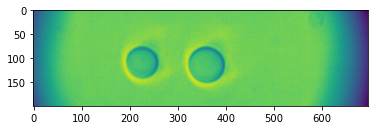

In [13]:
%matplotlib inline

import cv2 as cv
from matplotlib import pyplot as plt

imagePath = 'example_data/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000-004 IMAGE.png'
img = cv.imread(imagePath, cv.IMREAD_GRAYSCALE)

plt.imshow(img)
plt.show()
plt.close()

openCV loads the image into a two dimensional array

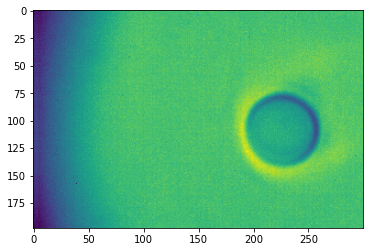

In [14]:
%matplotlib inline

import cv2 as cv
from matplotlib import pyplot as plt

imagePath = 'example_data/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000-004 IMAGE.png'
img = cv.imread(imagePath, cv.IMREAD_GRAYSCALE)

y_start = 0
y_end = -1
x_start = 0
x_end = 300
crop = img[y_start:y_end, x_start:x_end]

plt.imshow(crop)
plt.show()
plt.close()

openCV comes with some handy functions to filter your images

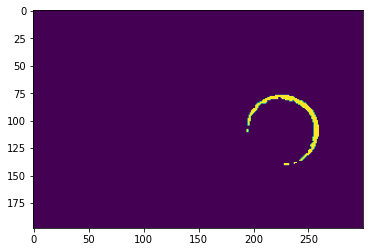

In [15]:
%matplotlib inline

import cv2 as cv
from matplotlib import pyplot as plt

imagePath = 'example_data/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000-004 IMAGE.png'
img = cv.imread(imagePath, cv.IMREAD_GRAYSCALE)

y_start = 0
y_end = -1
x_start = 0
x_end = 300
crop = img[y_start:y_end, x_start:x_end]

ks = 5 # kernel size
thr = 250 # threshold

mb1 = cv.medianBlur(crop, ks)
lapl = cv.Laplacian(mb1, ddepth=-1, ksize=ks)
equ = cv.equalizeHist(lapl)
_, thr = cv.threshold(equ, thr, 255, cv.THRESH_BINARY)
mb2 = cv.medianBlur(thr, ks-2)

plt.imshow(mb2)
plt.show()
plt.close()

openCV also has a function that finds contours

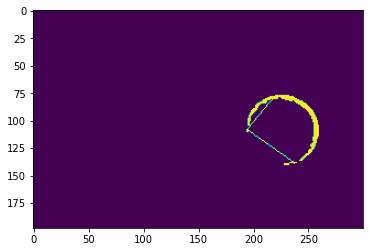

In [16]:
%matplotlib inline

import cv2 as cv
from matplotlib import pyplot as plt

imagePath = 'example_data/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000-004 IMAGE.png'
img = cv.imread(imagePath, cv.IMREAD_GRAYSCALE)

y_start = 0
y_end = -1
x_start = 0
x_end = 300
crop = img[y_start:y_end, x_start:x_end]

ks = 5 # kernel size
thr = 250 # threshold

mb1 = cv.medianBlur(crop, ks)
lapl = cv.Laplacian(mb1, ddepth=-1, ksize=ks)
equ = cv.equalizeHist(lapl)
_, thr = cv.threshold(equ, thr, 255, cv.THRESH_BINARY)
mb2 = cv.medianBlur(thr, ks-2)

# finding contours
contours, hierarchy = cv.findContours(mb2, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    cv.drawContours(mb2,[cnt],0,255,-1)
# finding contours of contours
contours, hierarchy = cv.findContours(mb2, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
# fix open contours
for i in range(1, len(contours)):
    cv.line(mb2, tuple(contours[i-1][0][0]), tuple(contours[i][0][0]),(255,255,255))

plt.imshow(mb2)
plt.show()
plt.close()

after image processing, the droplet size can be determined

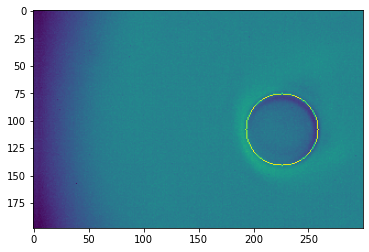

In [17]:
%matplotlib inline

import cv2 as cv
from matplotlib import pyplot as plt

imagePath = 'example_data/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000-004 IMAGE.png'
img = cv.imread(imagePath, cv.IMREAD_GRAYSCALE)

y_start = 0
y_end = -1
x_start = 0
x_end = 300
crop = img[y_start:y_end, x_start:x_end]

ks = 5 # kernel size
thr = 250 # threshold

mb1 = cv.medianBlur(crop, ks)
lapl = cv.Laplacian(mb1, ddepth=-1, ksize=ks)
equ = cv.equalizeHist(lapl)
_, thr = cv.threshold(equ, thr, 255, cv.THRESH_BINARY)
mb2 = cv.medianBlur(thr, ks-2)

# finding contours
contours, hierarchy = cv.findContours(mb2, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    cv.drawContours(mb2,[cnt],0,255,-1)
# finding contours of contours
contours, hierarchy = cv.findContours(mb2, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
# fix open contours
for i in range(1, len(contours)):
    cv.line(mb2, tuple(contours[i-1][0][0]), tuple(contours[i][0][0]),(255,255,255))

# finding contours of contours of contours
contours, hierarchy = cv.findContours(mb2, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
foundCenter, foundRadius = cv.minEnclosingCircle(contours[0])

center, radius = cv.minEnclosingCircle(contours[0])
centerX, centerY = [int(c) for c in center]
radius = int(radius)

cv.circle(crop, (centerX, centerY), radius, (255,255,0), thickness=1)

plt.imshow(crop)
plt.show()
plt.close()

In [114]:
import cv2 as cv
import numpy as np
from math import sqrt

def img_mradius_21_03(img, savePath=None, crp=[0,0,-1,-1], ks=5, thr=250, scale=1):
    """
    Uses openCV to draw a circle around the dropelts and measure the radius of that circle.
    Since this is not always reliable, it is recommended to always check the found circles.
    """
    x_start = crp[0]
    y_start = crp[1]
    x_end = crp[2]
    y_end= crp[3]
    
    crop = img[y_start:y_end, x_start:x_end]

    mb1 = cv.medianBlur(crop, ks)
    lapl = cv.Laplacian(mb1, ddepth=-1, ksize=ks)
    equ = cv.equalizeHist(lapl)
    ____, thr = cv.threshold(equ, thr, 255, cv.THRESH_BINARY)
    mb2 = cv.medianBlur(thr, ks-2)

    pos_drops = np.zeros(np.shape(mb2)[1])
    pos_inv = np.zeros(np.shape(mb2)[1])

    for i in range(np.shape(mb2)[1]):
        if np.sum(mb2,axis=0)[i] != 0:
            pos_drops[i] = i
        else:
            pos_inv[i] = i
        
    mid = int(np.sum(pos_drops) / len(pos_drops[pos_drops!=0]))
    cut = (np.abs(mid - pos_inv)).argsort()[0]

    part1 = mb2[:,:cut].copy()
    part2 = mb2[:,cut:].copy()
    
    #part 1

    contours, hierarchy = cv.findContours(part1, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    
    # Check: No contours found (part1)
    if len(contours)==0:
        r1 = 0
        c1 = (0,0)
        img_err_1 = 1
    
    else:
        for cnt in contours:
            cv.drawContours(part1,[cnt],0,255,-1)
        contours, hierarchy = cv.findContours(part1, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    
        # Check: No contours found (2nd time)
        if len(contours) == 0:
            r1 = 0
            c1 = (0,0)
            img_err_1 = 1
    
        elif len(contours) >=1:
            for i in range(1, len(contours)):
                cv.line(part1, tuple(contours[i-1][0][0]), tuple(contours[i][0][0]),(255,255,255))
        
            contours, hierarchy = cv.findContours(part1, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
            c1, r1 = cv.minEnclosingCircle(contours[0])
            img_err_1 = 0

    #part 2
    
    contours, hierarchy = cv.findContours(part2, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    
    # Check: No contours found
    if len(contours)==0:
        r2 = 0
        c2 = (0,0)
        img_err_2 = 1    
    
    else:
        for cnt in contours:
            cv.drawContours(part2,[cnt],0,255,-1)
        contours, hierarchy = cv.findContours(part2, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    
        # Check: No contours found (2nd time)
        if len(contours) == 0:
            r2 = 0
            c2 = (0,0)
            img_err_2 = 1

        elif len(contours) >=1:
            for i in range(1, len(contours)):
                cv.line(part2, tuple(contours[i-1][0][0]), tuple(contours[i][0][0]),(255,255,255))
        
            contours, hierarchy = cv.findContours(part2, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
            c2, r2 = cv.minEnclosingCircle(contours[0])
            img_err_2 = 0

    copy = imageLarge3C = cv.merge((crop, crop, crop))
    cv.circle(copy, (int(c1[0]), int(c1[1])), int(r1), (255,255,0), thickness=1)
    cv.circle(copy, (cut+int(c2[0]), int(c2[1])), int(r2), (255,255,0), thickness=1)

    if savePath:
        cv.imwrite(savePath.as_posix(), copy)
    
    img_err = img_err_1 + img_err_2
    
    if img_err == 0:
        mean_radius = sqrt(r1*r2)
        # 1 pixel equals 0.043 um
        mean_radius = mean_radius*0.043
    else:
        mean_radius = 0
    
    return mean_radius, img_err

example on how to use

In [115]:
imagePath = 'example_data/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000/2021-08-25_12-37-22 EWSR1_EE_10_1_DNA #000-004 IMAGE.png'
img = cv.imread(imagePath, cv.IMREAD_GRAYSCALE)

mean_radius, _ = img_mradius_21_03(img)

print(f'the geometric mean of the droplet radii is {mean_radius} um')

the geometric mean of the droplet radii is 1.5291617792915417 um
